# MGMT 590 — LendingClub Loan Default Risk (Indiana Borrowers)
## Phase 4A: Explainable AI & Risk Scoring

**Course:** MGMT 59000, Summer 2026, Section DY2 — Purdue University

**Builds on:** Phase 1 (data pipeline), Phase 2 (EDA), Phase 3 (Logistic
Regression / Random Forest / XGBoost, tuned and evaluated).

**Scope of this notebook:** demonstrate the four new reusable Phase 4A
modules -- `src/configurable_thresholds.py`, `src/interpretation_utils.py`,
`src/risk_scoring.py`, `src/explainability.py` -- against the Phase 3
production model. This notebook is a thin demonstration/validation layer;
essentially all logic lives in those modules so the Streamlit dashboard
(Phase 5) can import `RiskScoringEngine` and `ExplainabilityEngine`
directly without modification.

**Not implemented here (explicitly deferred):** the Streamlit dashboard
itself (Phase 5) and borrower clustering (Phase 4B).

> **Note on data:** as in Phases 1-3, this notebook runs against
> whatever is currently at `data/splits/` and `models/`. If these still
> reflect the synthetic test fixture rather than the real ~37,515-row
> Indiana LendingClub extract, treat every specific number, factor
> ranking, and business claim below as illustrative of the *mechanism*
> only, not as a real finding -- re-run Phases 1, 3, and this notebook
> once the genuine data is in place.


In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, utils, model_utils, interpretation_utils as iu
from src.configurable_thresholds import load_threshold_config
from src.risk_scoring import RiskScoringEngine, expand_threshold_analysis, plot_expanded_threshold_analysis
from src.explainability import ExplainabilityEngine, DEFAULT_INTERACTION_PAIRS

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train, X_val, X_test, y_train, y_val, y_test = utils.load_splits()
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Production model: {config.PRODUCTION_MODEL_KEY}")


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_train.csv — shape=(1049, 21)


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_val.csv — shape=(226, 21)


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_test.csv — shape=(225, 21)


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_train.csv — shape=(1049, 1)


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_val.csv — shape=(226, 1)


2026-07-31 04:24:16 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/y_test.csv — shape=(225, 1)


Train: (1049, 21) | Val: (226, 21) | Test: (225, 21)
Production model: xgboost


## 1. Configurable Business Thresholds

`src/configurable_thresholds.py` centralizes every business-policy
boundary (risk tiers, lending actions, interest-rate adjustments,
loan-grade bands) as a `RiskThresholdConfig` dataclass with a JSON load/
save API — a lending-operations stakeholder can edit
`reports/risk_threshold_config.json` directly, with no code change or
redeploy required. Loading it here also self-bootstraps that file on
first run.

In [3]:
threshold_config = load_threshold_config()
pd.DataFrame([vars(t) for t in threshold_config.risk_tiers])


2026-07-31 04:24:16 | INFO     | src.configurable_thresholds | Loaded risk threshold configuration from /home/claude/mgmt590_capstone/reports/risk_threshold_config.json


2026-07-31 04:24:16 | INFO     | src.configurable_thresholds | Risk threshold configuration validated successfully.


,name,min_probability,max_probability,description
0,Low Risk,0.0000,0.1500,Strong repayment profile; default probability ...
1,Moderate Risk,0.1500,0.3500,Acceptable repayment profile with some risk fa...
2,High Risk,0.3500,0.6000,Elevated default probability; multiple risk fa...
3,Very High Risk,0.6000,1.0100,Default probability is high; approval is not r...


In [4]:
pd.DataFrame([vars(a) for a in threshold_config.lending_actions])


,tier,action,description
0,Low Risk,Approve,Proceed with standard underwriting terms.
1,Moderate Risk,Approve with Conditions,Approve with a rate adjustment and/or reduced ...
2,High Risk,Manual Review,Route to a credit analyst for manual review be...
3,Very High Risk,Decline,Decline under standard policy; only proceed vi...


In [5]:
pd.Series(threshold_config.interest_rate_adjustment_bps, name="rate_adjustment_bps").to_frame()


,rate_adjustment_bps
Low Risk,-50.0000
Moderate Risk,0.0000
High Risk,150.0000
Very High Risk,400.0000


In [6]:
pd.DataFrame([vars(g) for g in threshold_config.loan_grade_bands])


,grade,min_probability,max_probability
0,A,0.0000,0.0800
1,B,0.0800,0.1500
2,C,0.1500,0.2500
3,D,0.2500,0.4000
4,E,0.4000,0.5500
5,F,0.5500,0.7000
6,G,0.7000,1.0100


**Design note:** these tiers are DELIBERATELY distinct from Phase 3's
statistically cost-minimizing decision threshold for each model
(`reports/threshold_analysis.joblib`). Phase 3's threshold answers "where
do we draw the line to minimize expected cost"; the tiers here answer
"how do we communicate and act on a *spectrum* of risk" (including
partial actions like a rate markup or manual review, not just a binary
accept/decline). `RiskScoringEngine` uses both, for different purposes —
see Section 2.

## 2. Risk Scoring Engine

`RiskScoringEngine` wraps one fitted Phase 3 model and turns raw
borrower rows into a probability, a 0-100 risk score, a risk tier, a
confidence score, and recommended action / interest rate / loan grade —
every business boundary read from `RiskThresholdConfig`, nothing
hard-coded.

In [7]:
risk_engine = RiskScoringEngine()  # defaults to config.PRODUCTION_MODEL_KEY
print(f"Model: {risk_engine.model_display_name}")
print(f"Phase 3 cost-minimizing decision threshold: {risk_engine._decision_threshold:.2f}")


2026-07-31 04:24:16 | INFO     | src.configurable_thresholds | Loaded risk threshold configuration from /home/claude/mgmt590_capstone/reports/risk_threshold_config.json


2026-07-31 04:24:16 | INFO     | src.configurable_thresholds | Risk threshold configuration validated successfully.


2026-07-31 04:24:16 | INFO     | src.risk_scoring | Loading XGBoost pipeline from /home/claude/mgmt590_capstone/models/xgboost_model.joblib


2026-07-31 04:24:16 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/models/xgboost_model.joblib


2026-07-31 04:24:16 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/threshold_analysis.joblib


2026-07-31 04:24:16 | INFO     | src.risk_scoring | RiskScoringEngine ready: model=XGBoost, decision_threshold=0.05


Model: XGBoost
Phase 3 cost-minimizing decision threshold: 0.05


### 2.1 Single-borrower prediction summary

In [8]:
example_borrower = X_test.iloc[[0]]
summary = risk_engine.generate_prediction_summary(example_borrower)
pd.Series(summary.to_dict())


default_probability                                                                    0.1627
risk_score                                                                            16.3000
risk_tier                                                                       Moderate Risk
risk_tier_description                       Acceptable repayment profile with some risk fa...
confidence_score                                                                      67.5000
recommended_action                                                    Approve with Conditions
recommended_action_description              Approve with a rate adjustment and/or reduced ...
recommended_interest_rate                                                             10.0000
recommended_interest_rate_adjustment_bps                                               0.0000
recommended_loan_grade                                                                      C
dtype: object

### 2.2 Portfolio-level risk-tier distribution

`generate_batch_summary` is the vectorized equivalent — useful for
reporting on an entire loan book rather than one application-time
decision.

In [9]:
batch_summary = risk_engine.generate_batch_summary(X_test)
batch_summary["risk_tier"].value_counts().reindex(
    [t.name for t in threshold_config.risk_tiers]
).fillna(0).astype(int)


risk_tier
Low Risk          95
Moderate Risk     46
High Risk         53
Very High Risk    31
Name: count, dtype: int64

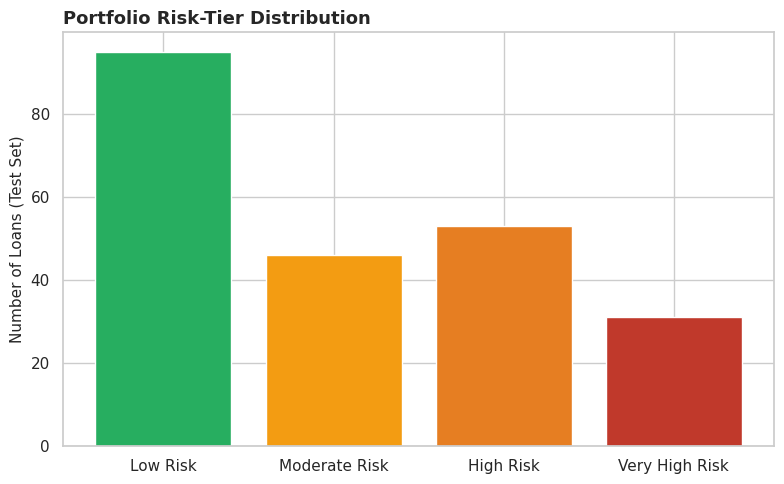

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
tier_order = [t.name for t in threshold_config.risk_tiers]
counts = batch_summary["risk_tier"].value_counts().reindex(tier_order).fillna(0)
colors = ["#27AE60", "#F39C12", "#E67E22", "#C0392B"]
ax.bar(counts.index, counts.values, color=colors)
ax.set_ylabel("Number of Loans (Test Set)")
ax.set_title("Portfolio Risk-Tier Distribution", fontsize=13, fontweight="bold", loc="left")
fig.tight_layout()
plt.show()


**Business interpretation:** this is the shape of the loan book under
the current model and thresholds — a portfolio skewed heavily toward
"Very High Risk" would suggest either the applicant pool itself is risky
or the tier boundaries need revisiting; skewed heavily toward "Low Risk"
with very few declines suggests thresholds may be too permissive for the
observed default rate.

### 2.3 Exportable risk-assessment report

In [11]:
report = risk_engine.export_prediction_report(example_borrower)
print(report.to_markdown())


# Borrower Risk Assessment

## Model

XGBoost (production scoring model)

## Risk Assessment

Default probability: 16.3%

Risk score: 16.3/100

Risk tier: Moderate Risk -- Acceptable repayment profile with some risk factors present.

Confidence: 67.5/100

## Recommendation

Action: Approve with Conditions -- Approve with a rate adjustment and/or reduced principal to price in the added risk.

Recommended interest rate: 10.0% (+0 bps vs. base rate)

Model-driven loan grade: C



## 3. Expanded Threshold Optimization

Extends Phase 3's cost-minimizing threshold analysis with two more
business-facing figures: **approval rate** (what share of applicants
would be approved at this cutoff) and **false-positive/false-negative
rate** (as rates, not just counts folded into a cost number).

In [12]:
proba_val = risk_engine.predict_probability(X_val)
expanded_table = expand_threshold_analysis(y_val, proba_val)
expanded_table.head(10)


,threshold,precision,recall,specificity,f1_score,accuracy,expected_cost_per_loan,n_flagged_as_risky,approval_rate,false_positive_rate,false_negative_rate
0,0.0500,0.2737,0.8448,0.2262,0.4135,0.3850,0.7743,179,0.2080,0.7738,0.1552
1,0.1000,0.2566,0.6724,0.3274,0.3714,0.4159,0.9204,152,0.3274,0.6726,0.3276
2,0.1500,0.2462,0.5517,0.4167,0.3404,0.4513,1.0088,130,0.4248,0.5833,0.4483
3,0.2000,0.2407,0.4483,0.5119,0.3133,0.4956,1.0708,108,0.5221,0.4881,0.5517
4,0.2500,0.2258,0.3621,0.5714,0.2781,0.5177,1.1372,93,0.5885,0.4286,0.6379
5,0.3000,0.2289,0.3276,0.6190,0.2695,0.5442,1.1460,83,0.6327,0.3810,0.6724
6,0.3500,0.2286,0.2759,0.6786,0.2500,0.5752,1.1681,70,0.6903,0.3214,0.7241
7,0.4000,0.1833,0.1897,0.7083,0.1864,0.5752,1.2566,60,0.7345,0.2917,0.8103
8,0.4500,0.1837,0.1552,0.7619,0.1682,0.6062,1.2611,49,0.7832,0.2381,0.8448
9,0.5000,0.1395,0.1034,0.7798,0.1188,0.6062,1.3142,43,0.8097,0.2202,0.8966


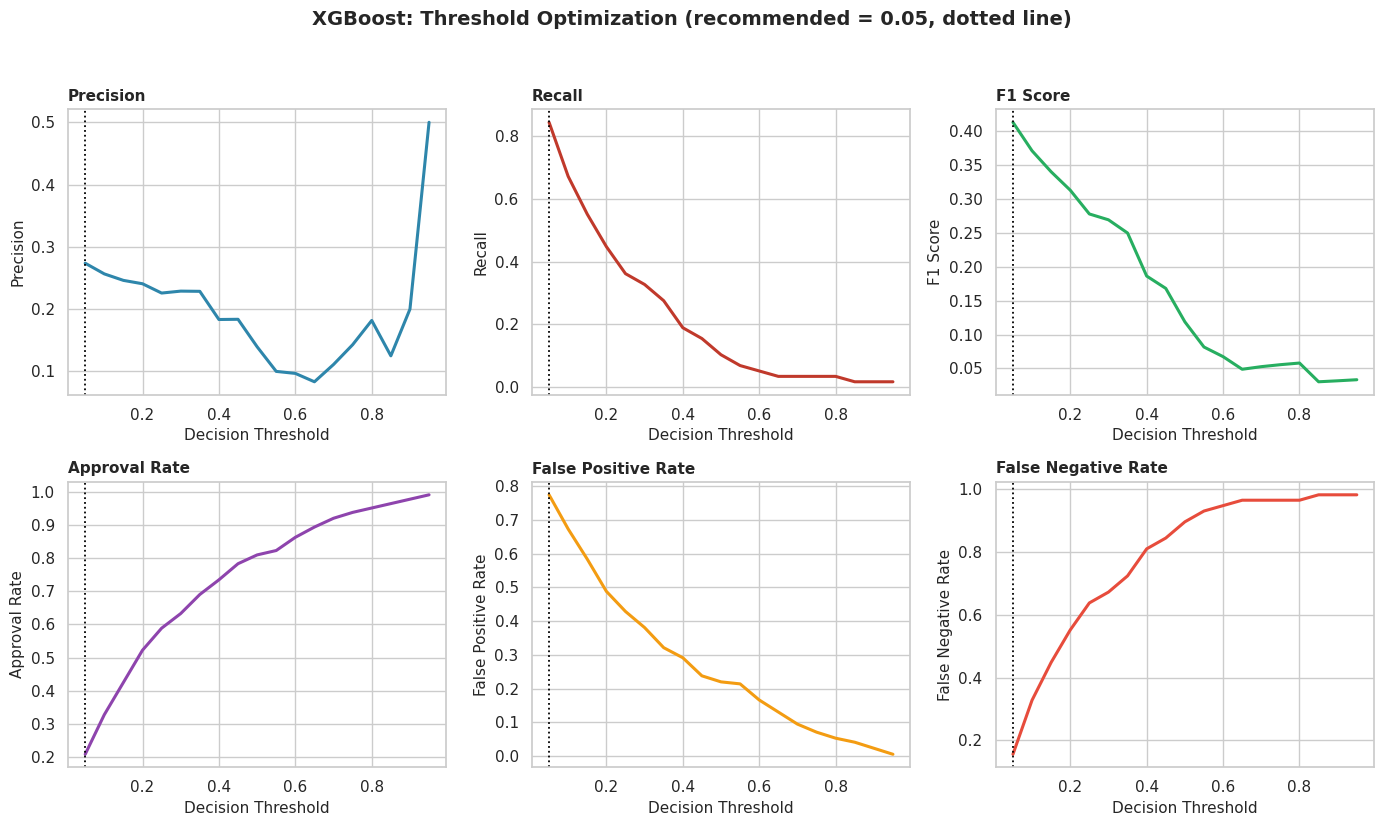

In [13]:
fig = plot_expanded_threshold_analysis(
    expanded_table, recommended_threshold=risk_engine._decision_threshold,
    model_display_name=risk_engine.model_display_name,
)
plt.show()


**Why this threshold was selected:** `risk_engine._decision_threshold`
is Phase 3's cost-minimizing cutoff (see `model_utils.recommend_threshold`),
computed on the VALIDATION set using the relative false-negative/false-
positive cost weights in `config.COST_FALSE_NEGATIVE` /
`config.COST_FALSE_POSITIVE`. **Which error type is costlier for Lending
Club:** a false negative (approving a borrower who actually defaults)
loses the principal and accrued interest and triggers collections costs
— a much larger loss than the forgone interest margin of a false
positive (declining a borrower who would have repaid). This is why
`config.COST_FALSE_NEGATIVE` (5.0) is set well above
`config.COST_FALSE_POSITIVE` (1.0), and why the recommended threshold
sits below 0.50 rather than at it — the model is deliberately biased
toward catching more defaulters at the cost of declining somewhat more
good borrowers.

## 4. Explainability Engine: Global Model Explanations

`ExplainabilityEngine` wraps the same production model with SHAP
(`TreeExplainer` for XGBoost/Random Forest, `LinearExplainer` for
Logistic Regression — see the module docstring in `explainability.py`
for why). SHAP values below are in the model's log-odds (margin) output
space, not raw probability — labeled accordingly on every plot.

In [14]:
explain_engine = ExplainabilityEngine()  # shares config.PRODUCTION_MODEL_KEY
print(f"Explainer: {type(explain_engine.explainer).__name__}")


2026-07-31 04:24:18 | INFO     | src.explainability | Loading XGBoost pipeline from /home/claude/mgmt590_capstone/models/xgboost_model.joblib


2026-07-31 04:24:18 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/models/xgboost_model.joblib


2026-07-31 04:24:18 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_train.csv — shape=(1049, 21)


2026-07-31 04:24:18 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_val.csv — shape=(226, 21)


2026-07-31 04:24:18 | INFO     | src.utils | Loaded dataframe from /home/claude/mgmt590_capstone/data/splits/X_test.csv — shape=(225, 21)


...

2026-07-31 04:24:18 | INFO     | src.configurable_thresholds | Risk threshold configuration validated successfully.


2026-07-31 04:24:18 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/threshold_analysis.joblib


2026-07-31 04:24:18 | INFO     | src.risk_scoring | RiskScoringEngine ready: model=XGBoost, decision_threshold=0.05


2026-07-31 04:24:18 | INFO     | src.explainability | ExplainabilityEngine ready: model=XGBoost, explainer=TreeExplainer, n_features=34, background_n=200


Explainer: TreeExplainer


### 4.1 SHAP Summary Plots (Beeswarm and Bar)

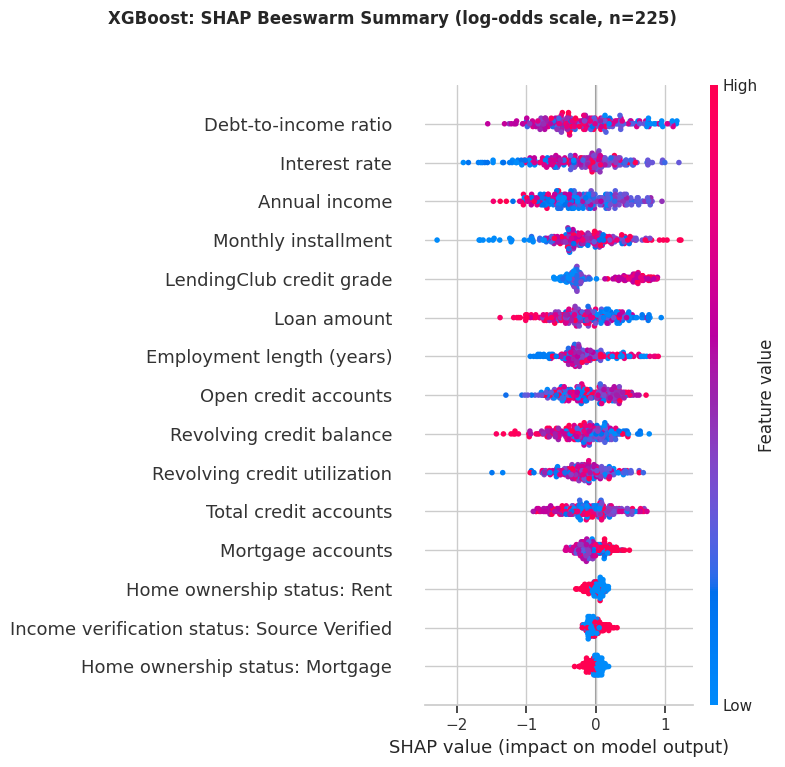

In [15]:
fig = explain_engine.generate_shap_summary(X_test, plot_type="beeswarm")
plt.show()


**Business interpretation:** each dot is one borrower; its horizontal
position is that borrower's SHAP value for the feature (how much that
feature pushed their prediction up/down), and its color is the
borrower's actual value for that feature (red = high, blue = low). A
feature where red dots cluster on the right and blue dots on the left
means higher values of this feature increase predicted default risk.

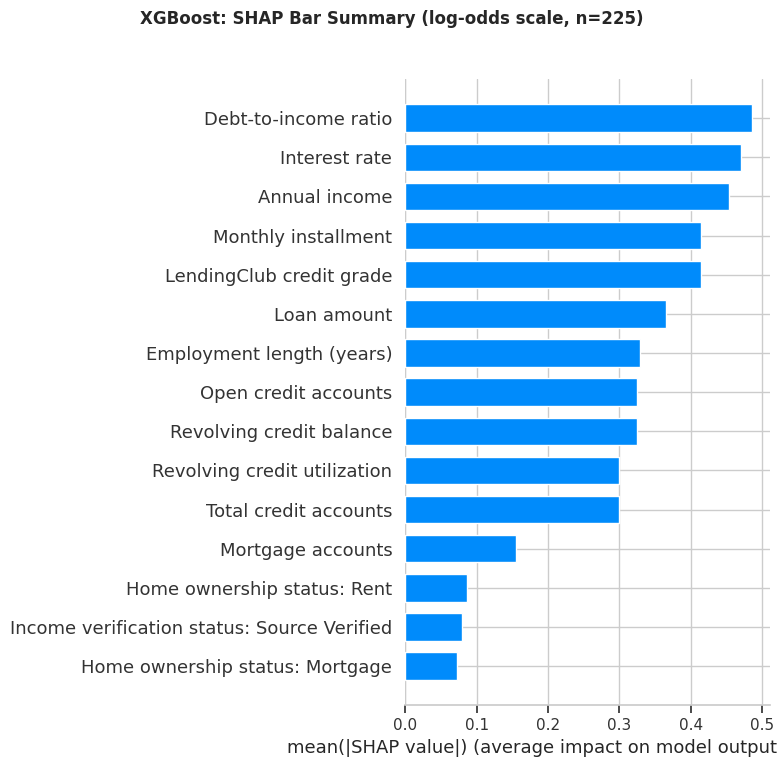

In [16]:
fig = explain_engine.generate_shap_summary(X_test, plot_type="bar")
plt.show()


### 4.2 Feature Importance Comparison

In [17]:
importance_table = explain_engine.summarize_feature_importance(X_test)
importance_table.head(15)


2026-07-31 04:24:19 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/feature_importance.joblib


,feature,feature_label,mean_abs_shap,research_question,native_importance,native_importance_type,permutation_importance
0,numeric__dti,Debt-to-income ratio,0.4862,RQ5 (does DTI influence default?),2.6205,Gain importance,-0.0222
1,numeric__int_rate,Interest rate,0.4700,RQ3 (which variables relate to higher interest...,2.3415,Gain importance,-0.0139
2,numeric__annual_inc,Annual income,0.4543,RQ4 (does income relate to repayment success?),2.1885,Gain importance,0.0123
3,numeric__installment,Monthly installment,0.4151,RQ1 (which borrower characteristics associate ...,2.2273,Gain importance,0.0085
4,ordinal_categorical__grade,LendingClub credit grade,0.4147,RQ2 (are LendingClub grades predictive of defa...,2.4394,Gain importance,-0.0116
5,numeric__loan_amnt,Loan amount,0.3650,RQ1 (which borrower characteristics associate ...,2.1480,Gain importance,0.0074
6,numeric__emp_length_years,Employment length (years),0.3288,RQ6 (does employment length matter?),2.4897,Gain importance,0.0129
7,numeric__open_acc,Open credit accounts,0.3252,RQ1 (which borrower characteristics associate ...,2.5531,Gain importance,-0.0084
8,numeric__revol_bal,Revolving credit balance,0.3248,RQ1 (which borrower characteristics associate ...,2.5534,Gain importance,-0.0003
9,numeric__revol_util,Revolving credit utilization,0.2994,RQ1 (which borrower characteristics associate ...,2.3452,Gain importance,-0.0065


**Comparing three independent importance methods** (SHAP mean |value|,
Phase 3's permutation importance, and the model's native importance) —
features ranked highly across ALL THREE are the most trustworthy
candidates for "genuinely predictive," versus a feature that only one
method rates highly, which may reflect that method's own biases (e.g.
impurity importance's known bias toward high-cardinality features,
discussed in Phase 3).

### 4.3 Global Model Explanation and Executive Summary

In [18]:
global_explanation = explain_engine.explain_global_model(X_test)
print(global_explanation.business_summary)


2026-07-31 04:24:19 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/feature_importance.joblib


Across the full borrower population, the XGBoost model's predictions are most strongly driven by debt-to-income ratio, interest rate, annual income, monthly installment, and LendingClub credit grade. By comparison, loan purpose: Major Purchase, public derogatory records, and loan purpose: Other contribute comparatively little to the model's predictions and are lower-priority for data-collection efforts.


In [19]:
print("Most influential variables:")
for f in global_explanation.top_features:
    print(f"  - {f}")
print("\nLeast influential variables:")
for f in global_explanation.least_influential_features:
    print(f"  - {f}")
print("\nPositive contributors to default risk (higher value -> higher risk):")
for f in global_explanation.positive_contributors:
    print(f"  - {f}")
print("\nNegative contributors to default risk (higher value -> lower risk, i.e. protective):")
for f in global_explanation.negative_contributors:
    print(f"  - {f}")


Most influential variables:
  - Debt-to-income ratio
  - Interest rate
  - Annual income
  - Monthly installment
  - LendingClub credit grade
  - Loan amount
  - Employment length (years)
  - Open credit accounts

Least influential variables:
  - Loan purpose: Major Purchase
  - Public derogatory records
  - Loan purpose: Other
  - Application type: Joint App
  - Loan term: 60 Months
  - Loan purpose: Home Improvement
  - Loan purpose: Small Business
  - Home ownership status: Other

Positive contributors to default risk (higher value -> higher risk):
  - LendingClub credit grade
  - Loan purpose: Major Purchase
  - Loan purpose: Small Business

Negative contributors to default risk (higher value -> lower risk, i.e. protective):
  - Interest rate
  - Annual income
  - Revolving credit utilization
  - Revolving credit balance
  - Monthly installment
  - Debt-to-income ratio
  - Employment length (years)
  - Loan amount


### 4.4 SHAP Dependence Plots

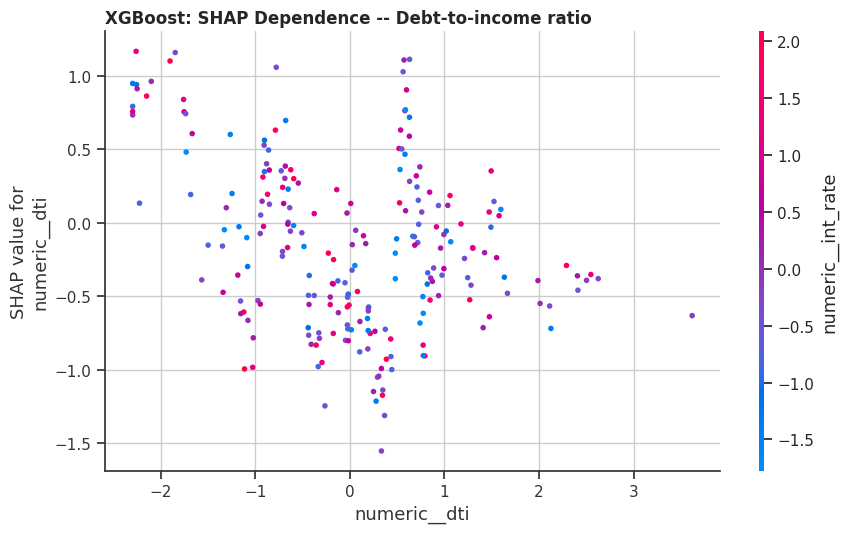

In [20]:
fig = explain_engine.generate_dependence_plot("dti", X_test, interaction_feature="int_rate")
plt.show()


**Business interpretation:** the x-axis is the borrower's actual DTI;
the y-axis is how much that DTI value contributed to their predicted
risk (in log-odds). An upward-sloping pattern confirms higher DTI raises
predicted risk; color (by interest rate) reveals whether that
relationship is stronger or weaker depending on the borrower's rate —
i.e. an interaction effect.

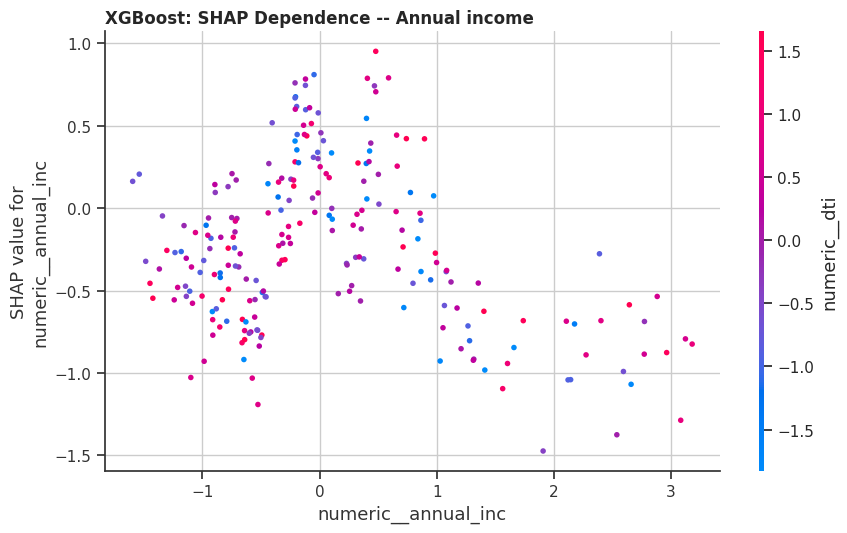

In [21]:
fig = explain_engine.generate_dependence_plot("annual_inc", X_test, interaction_feature="dti")
plt.show()


### 4.5 SHAP Decision Plot

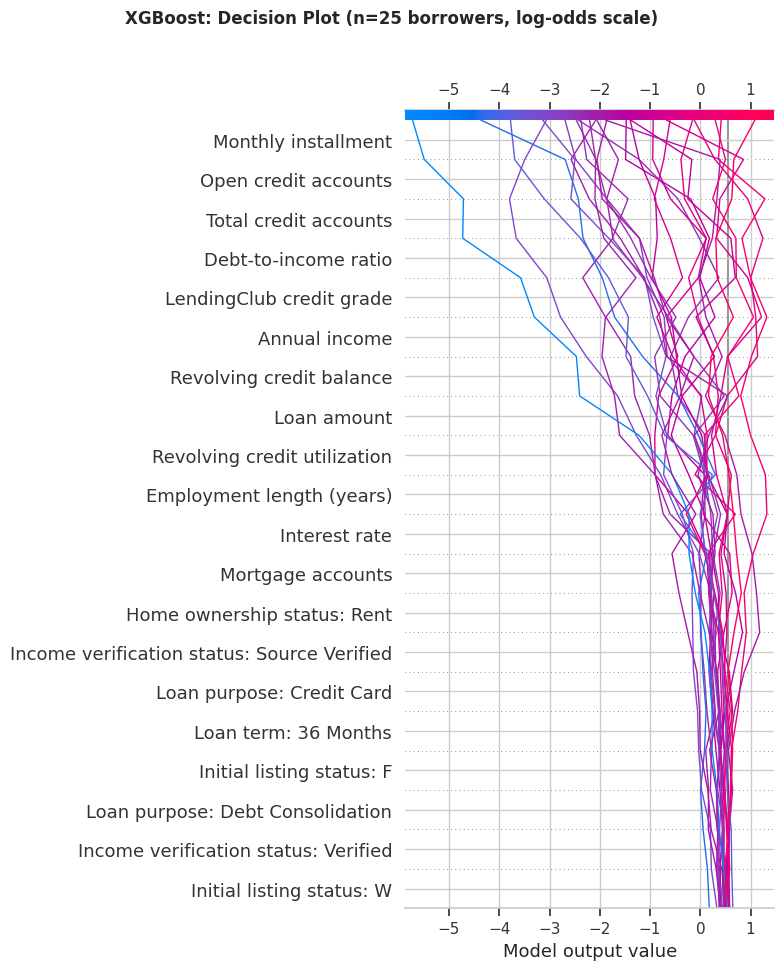

In [22]:
fig = explain_engine.generate_decision_plot(X_test, n_samples=25)
plt.show()


**Business interpretation:** each line is one borrower's cumulative
SHAP trajectory from the model's average prediction (left) to their
final predicted risk (right). Lines that diverge sharply from the
bundle partway through highlight borrowers whose risk is driven by an
unusual feature combination rather than the typical pattern — useful for
spotting edge cases a credit analyst should review manually.

## 5. Explainability Engine: Local (Individual Borrower) Explanations

For one specific borrower: SHAP waterfall and force plots, the top risk
and protective factors, and a plain-language business summary that
reads like something a credit analyst would write — no ML jargon.

In [23]:
local_explanation = explain_engine.explain_prediction(example_borrower)
print(local_explanation.business_summary)


This borrower is classified as Moderate Risk (estimated 16% likelihood of default). This is primarily driven by interest rate, total credit accounts, and loan amount. On the positive side, monthly installment and debt-to-income ratio help offset some of this risk. Recommended action: Approve with Conditions.


In [24]:
local_explanation.feature_contributions.head(10)


,feature,feature_label,shap_value,feature_value
0,numeric__installment,Monthly installment,-1.2194,-1.4720
1,numeric__dti,Debt-to-income ratio,-0.8338,-0.3572
2,numeric__int_rate,Interest rate,0.5677,2.0347
3,numeric__total_acc,Total credit accounts,0.5206,-0.3699
4,ordinal_categorical__grade,LendingClub credit grade,-0.3017,1.0000
5,numeric__annual_inc,Annual income,-0.2982,0.3084
6,numeric__loan_amnt,Loan amount,0.2557,-0.5587
7,numeric__mort_acc,Mortgage accounts,-0.2302,0.6883
8,numeric__emp_length_years,Employment length (years),-0.2198,-0.5722
9,numeric__revol_bal,Revolving credit balance,-0.2089,-0.4289


### 5.1 SHAP Waterfall Plot

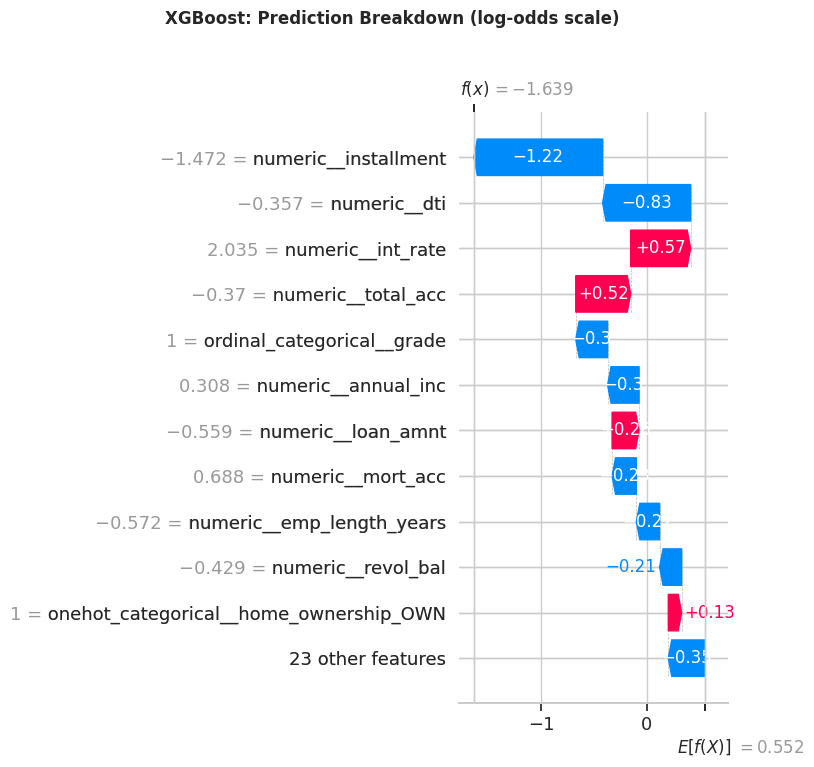

In [25]:
fig = explain_engine.generate_waterfall_plot(example_borrower)
plt.show()


**Business interpretation:** starting from the model's average
prediction (the base value, in log-odds), each bar shows how much one
feature moved this specific borrower's prediction up (red, toward higher
default risk) or down (blue, toward lower default risk), ending at their
final predicted value.

### 5.2 SHAP Force Plot

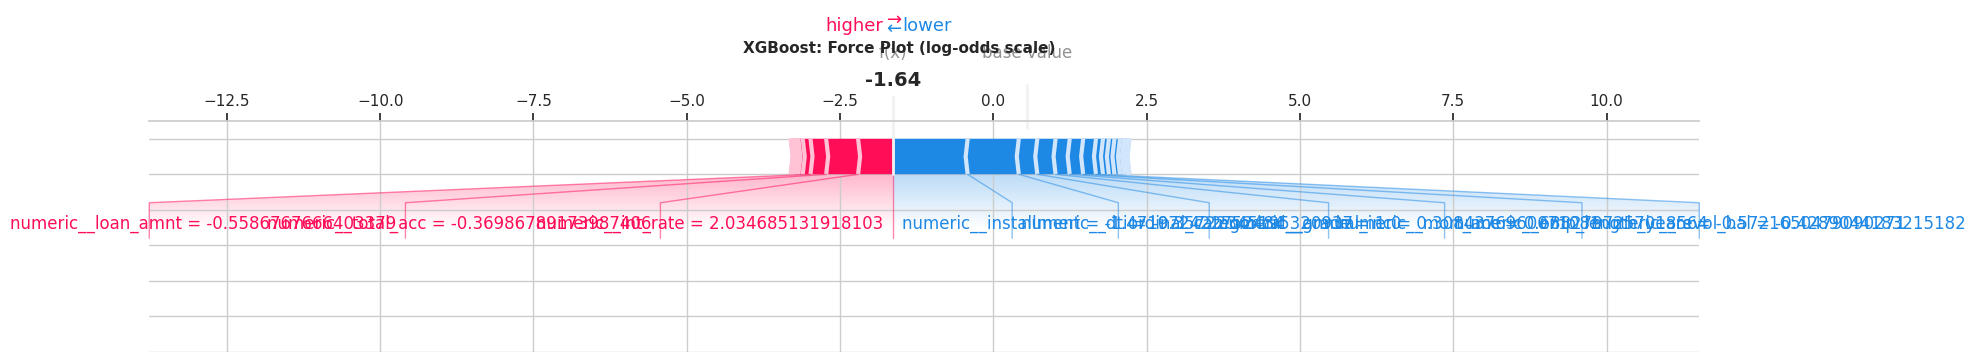

In [26]:
fig = explain_engine.generate_force_plot(example_borrower)
plt.show()


**Business interpretation:** the same additive attribution as the
waterfall plot, shown as opposing "push" forces — red features pushing
right (toward higher risk), blue features pushing left (toward lower
risk) — from the base value to the final prediction arrow.

### 5.3 Top Risk Factors and Top Protective Factors

In [27]:
print("Top risk factors:")
for f in local_explanation.top_risk_factors:
    print(f"  - {f}")
print("\nTop protective factors:")
for f in local_explanation.top_protective_factors:
    print(f"  - {f}")


Top risk factors:
  - Interest rate
  - Total credit accounts
  - Loan amount
  - Home ownership status: Own
  - Loan term: 36 Months

Top protective factors:
  - Monthly installment
  - Debt-to-income ratio
  - LendingClub credit grade
  - Annual income
  - Mortgage accounts


## 6. Feature Interaction Analysis

The five interaction pairs from the Phase 4A brief. Pairs where BOTH
sides resolve to a single numeric/ordinal column (Income x DTI,
Grade x Interest Rate, Employment Length x Income) use a SHAP dependence
plot colored by the interacting feature. Pairs involving a one-hot
categorical feature (Purpose x Grade, Home Ownership x DTI) instead use
a mean-predicted-risk heatmap, since SHAP's scatter-style dependence
plot cannot represent a multi-column categorical feature on one axis
(see the design note in `ExplainabilityEngine.analyze_feature_interactions`).

In [28]:
interaction_results = explain_engine.analyze_feature_interactions(X_test)

for (primary, interacting), result in interaction_results.items():
    print(f"=== {primary} x {interacting} ({result['kind']}) ===")


=== annual_inc x dti (shap_dependence) ===
=== grade x int_rate (shap_dependence) ===
=== emp_length_years x annual_inc (shap_dependence) ===
=== purpose x grade (heatmap) ===
=== home_ownership x dti (heatmap) ===


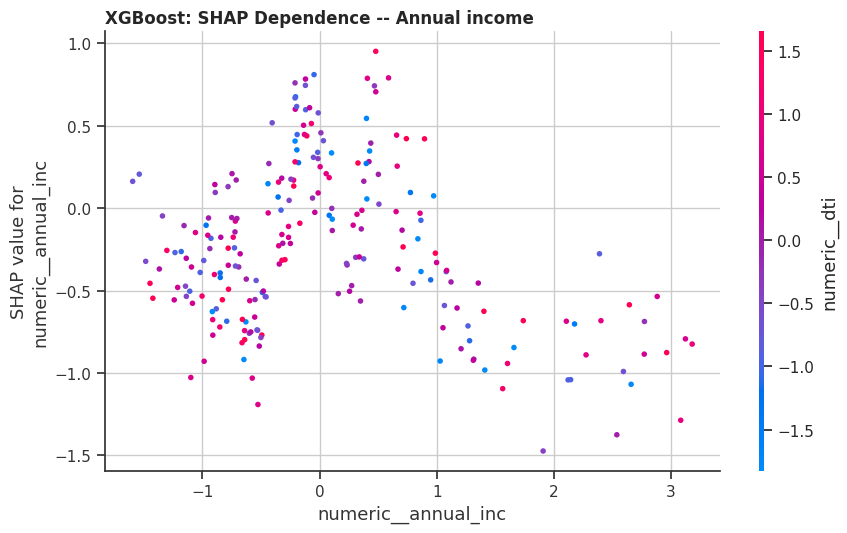

In [29]:
result = interaction_results[("annual_inc", "dti")]
result["figure"]


**Annual Inc x Dti:** see the printed interpretation below the combined cell in Section 6 for the generated business interpretation of this specific pair.

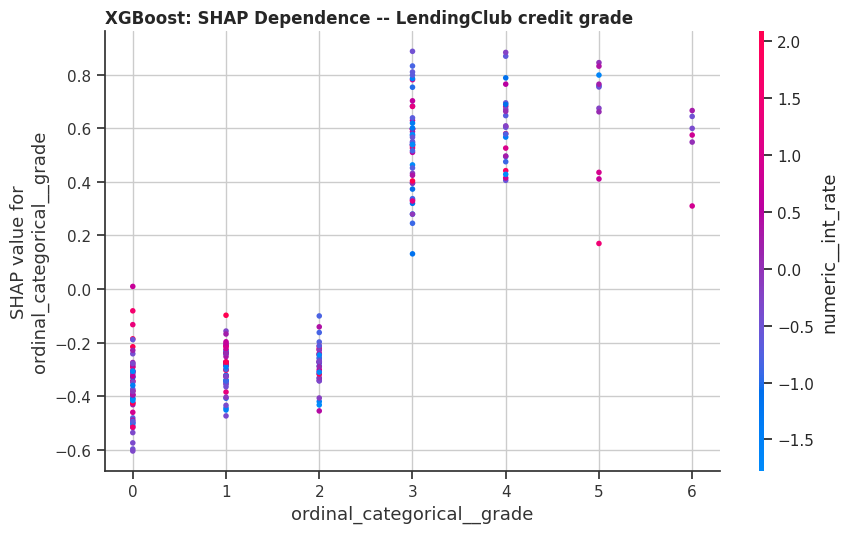

In [30]:
result = interaction_results[("grade", "int_rate")]
result["figure"]


**Grade x Int Rate:** see the printed interpretation below the combined cell in Section 6 for the generated business interpretation of this specific pair.

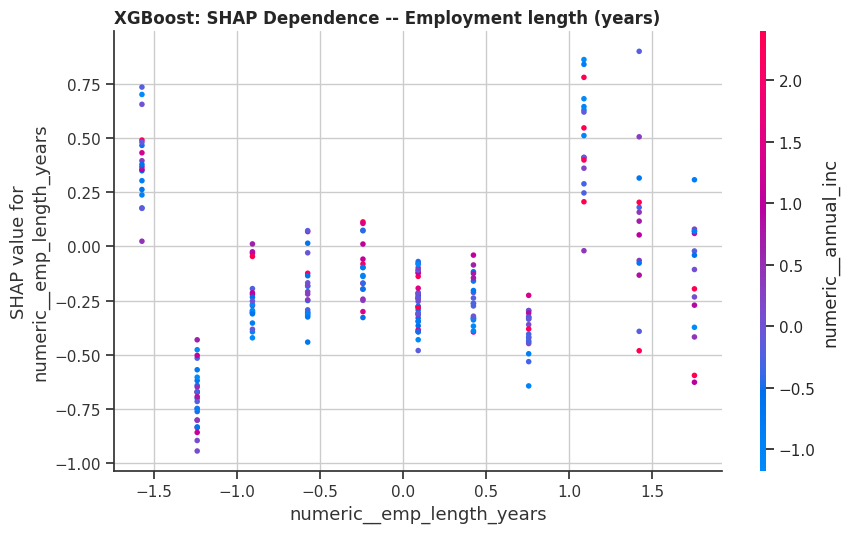

In [31]:
result = interaction_results[("emp_length_years", "annual_inc")]
result["figure"]


**Emp Length Years x Annual Inc:** see the printed interpretation below the combined cell in Section 6 for the generated business interpretation of this specific pair.

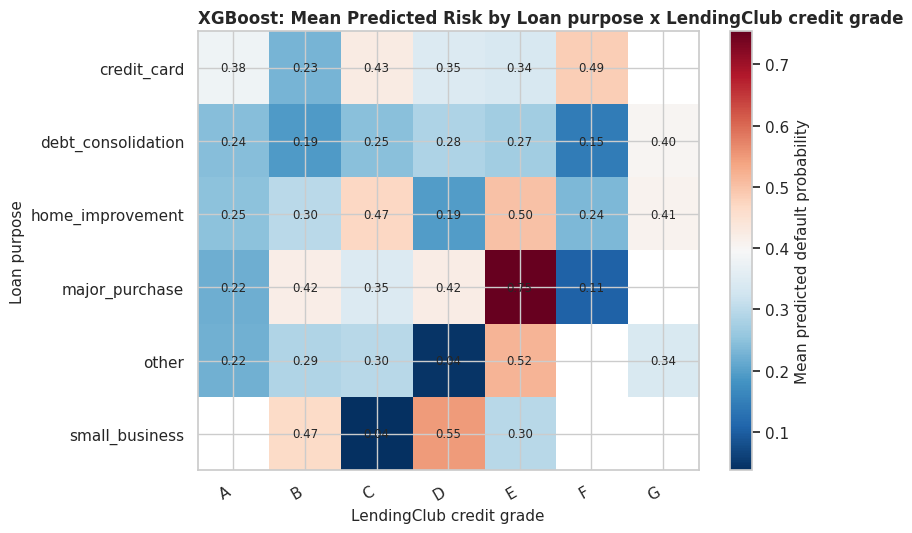

In [32]:
result = interaction_results[("purpose", "grade")]
result["figure"]


**Purpose x Grade:** see the printed interpretation below the combined cell in Section 6 for the generated business interpretation of this specific pair.

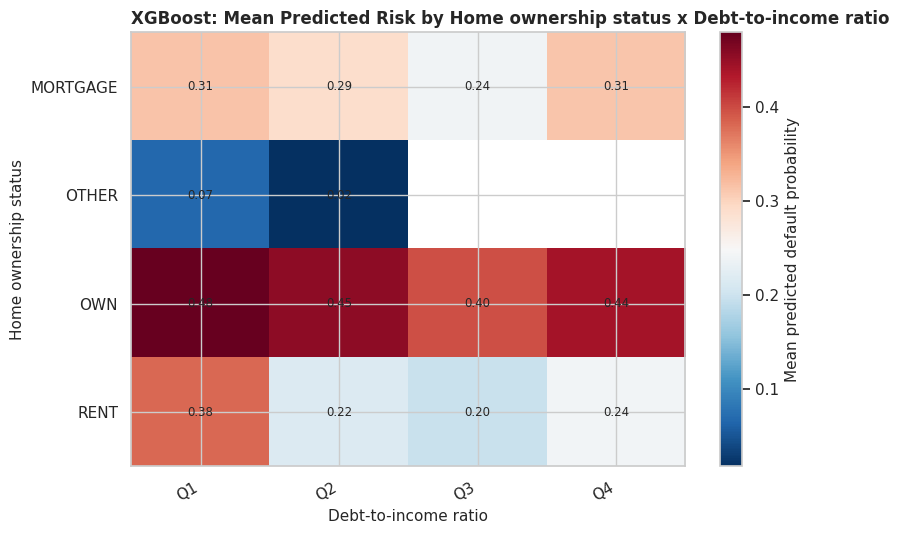

In [33]:
result = interaction_results[("home_ownership", "dti")]
result["figure"]


**Home Ownership x Dti:** see the printed interpretation below the combined cell in Section 6 for the generated business interpretation of this specific pair.

In [34]:
for (primary, interacting), result in interaction_results.items():
    print(f"--- {primary} x {interacting} ---")
    print(result["interpretation"])
    print()


--- annual_inc x dti ---
Vertical spread of points at a given Annual income value, and the color gradient by Debt-to-income ratio, both indicate how much Debt-to-income ratio changes the effect of Annual income on predicted risk -- a flat, uncolored-looking band would indicate little interaction, while a clear color gradient at fixed x-values indicates a meaningful interaction.

--- grade x int_rate ---
Vertical spread of points at a given LendingClub credit grade value, and the color gradient by Interest rate, both indicate how much Interest rate changes the effect of LendingClub credit grade on predicted risk -- a flat, uncolored-looking band would indicate little interaction, while a clear color gradient at fixed x-values indicates a meaningful interaction.

--- emp_length_years x annual_inc ---
Vertical spread of points at a given Employment length (years) value, and the color gradient by Annual income, both indicate how much Annual income changes the effect of Employment length (y

## 7. Partial Dependence and ICE Plots

A second, model-agnostic (non-SHAP) lens on marginal effects, computed
directly on the fitted `Pipeline` via scikit-learn's
`PartialDependenceDisplay`. The thick line is the Partial Dependence
(average effect across all borrowers); the thin lines are Individual
Conditional Expectation curves (one per borrower) — divergence among ICE
lines signals the marginal effect is NOT uniform across borrowers (an
interaction with some other feature, even though PDP alone wouldn't show
which one).

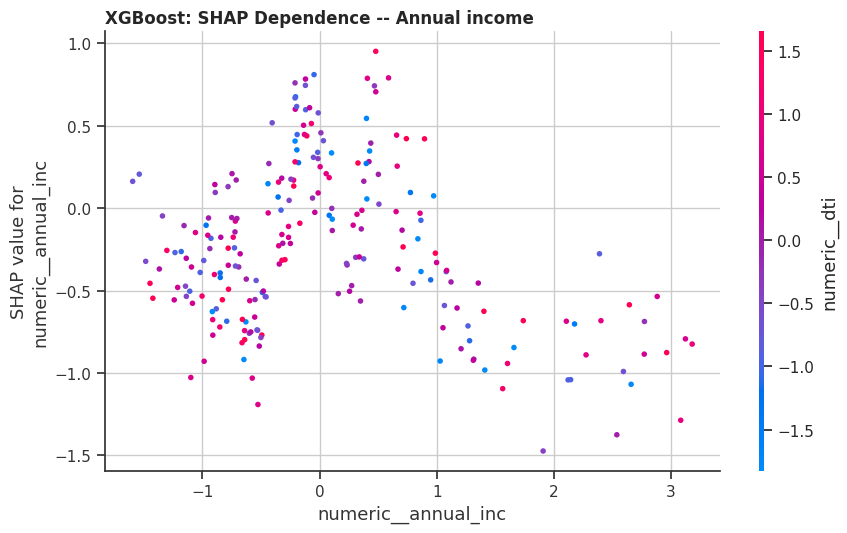

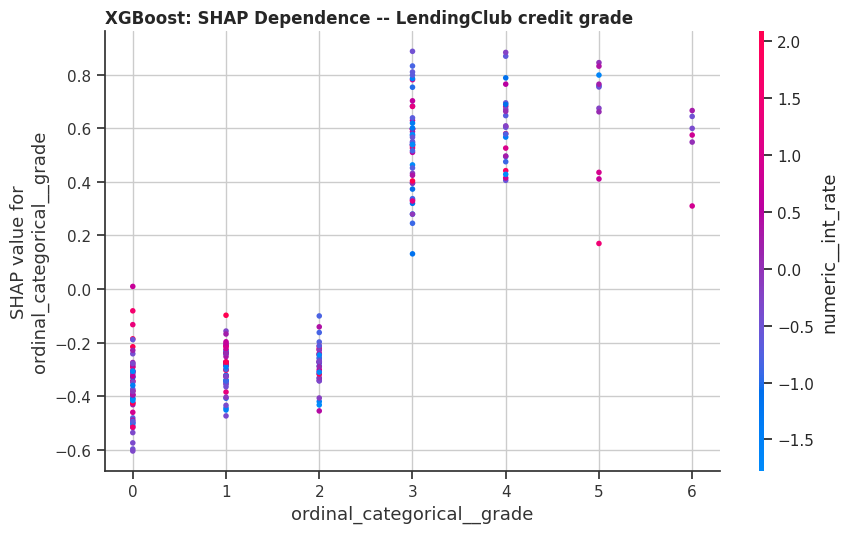

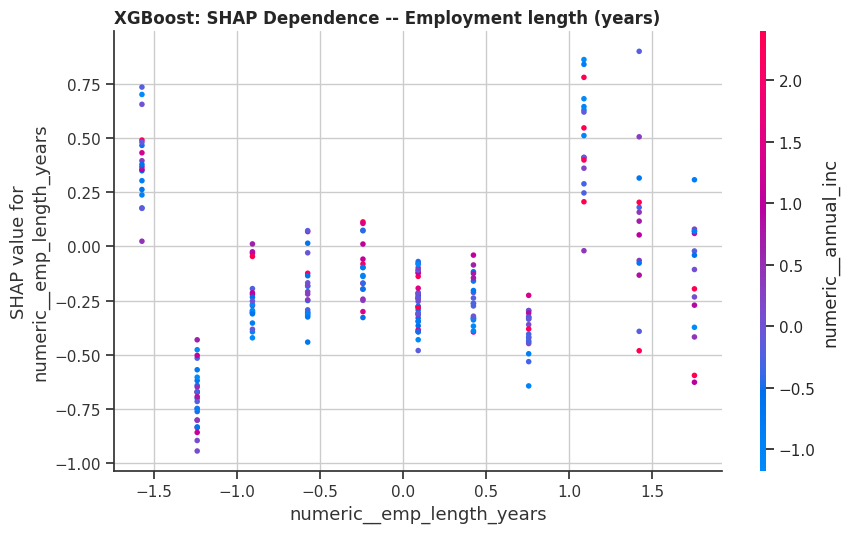

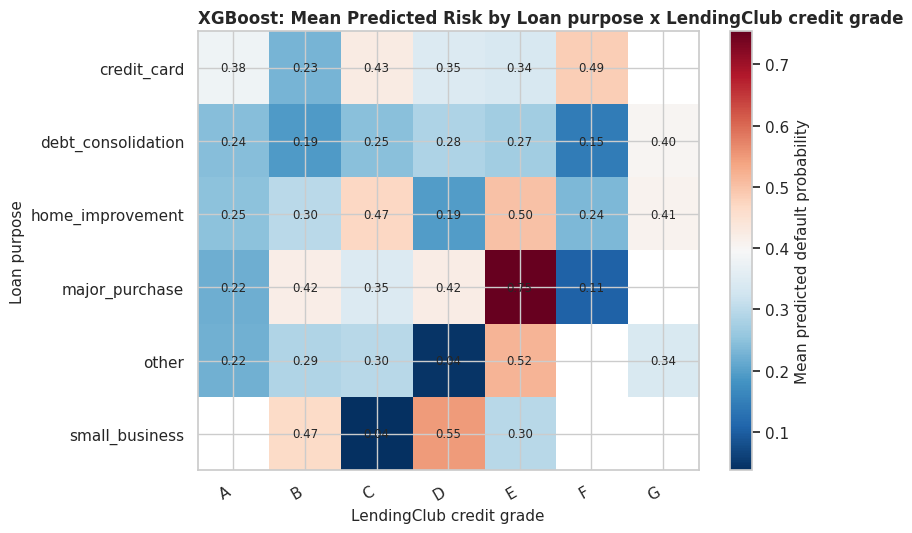

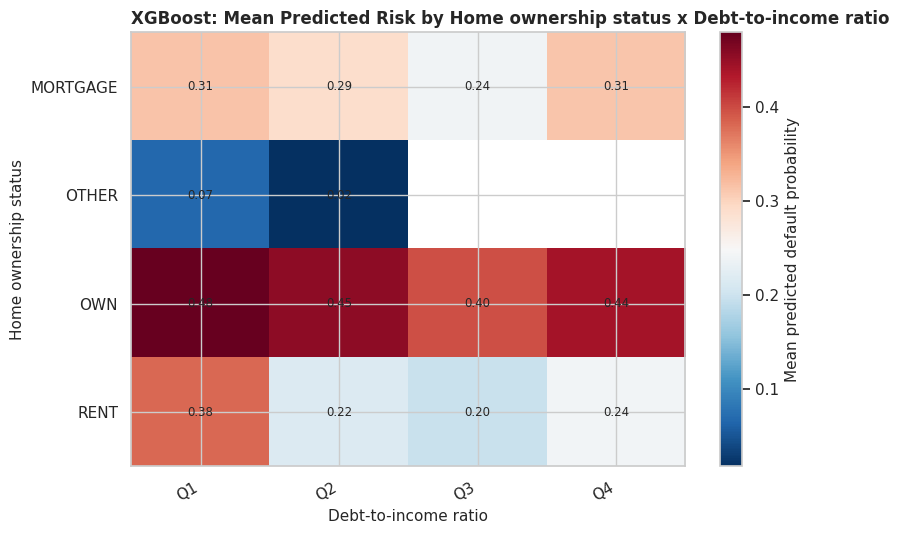

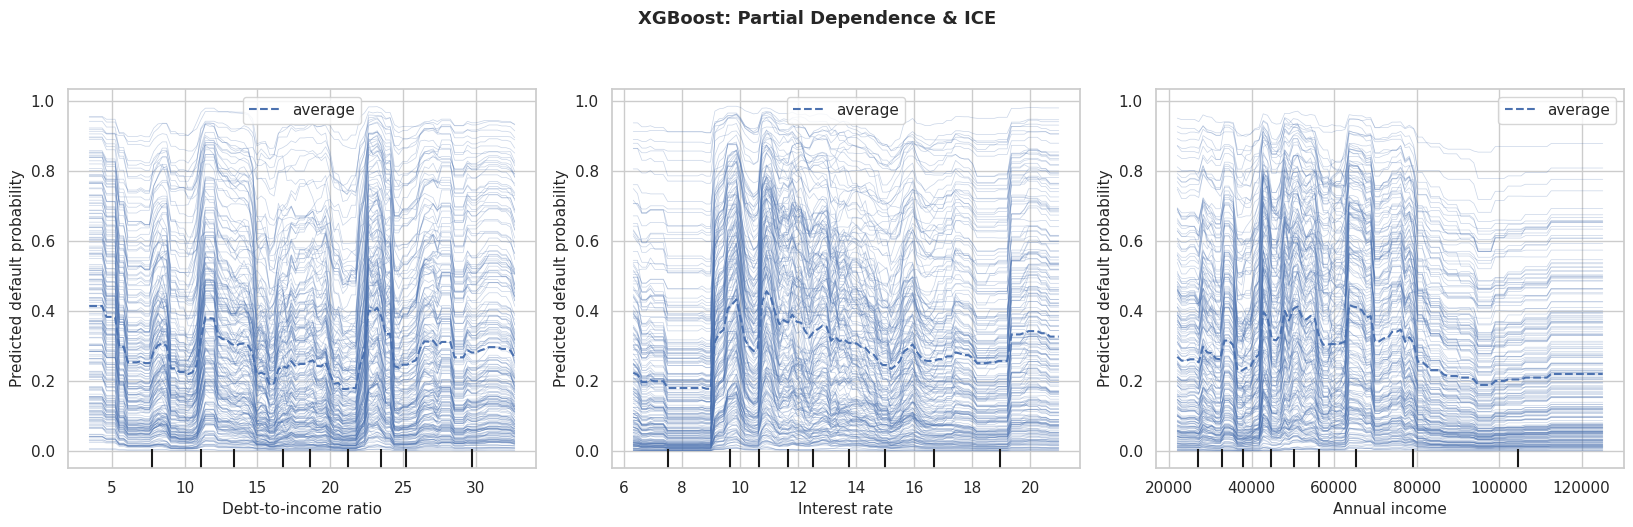

In [35]:
fig = explain_engine.generate_pdp_ice_plot(X_test, features=["dti", "int_rate", "annual_inc"], kind="both")
plt.show()


**Business interpretation:** a rising PD line for DTI confirms the
marginal effect of debt burden on predicted risk holds "all else equal";
a flattening slope past some DTI level would indicate a threshold effect
(risk stops climbing meaningfully beyond that point) rather than a
purely linear relationship — relevant for setting a DTI-based underwriting
cutoff versus a continuous rate adjustment.

## 8. Model Fairness Assessment

**Important limitation, stated up front:** this dataset contains no
legally protected class attributes (race, gender, age, religion,
national origin, etc.) — it was never collected with them. This
assessment can only speak to performance parity across the
BUSINESS/FINANCIAL attributes actually present. It cannot support or
refute any claim about fairness with respect to legally protected
classes, and should not be represented as doing so.

In [36]:
proba_test = risk_engine.predict_probability(X_test)
fairness_table = iu.fairness_report(
    X_test, y_test, proba_test,
    group_columns=["home_ownership", "purpose", "grade"],
    threshold=risk_engine._decision_threshold,
)
fairness_table[["group_column", "group_value", "n_loans", "actual_default_rate", "recall", "precision", "roc_auc"]]


2026-07-31 04:24:30 | INFO     | src.interpretation_utils | Skipping fairness row for home_ownership=OTHER (n=2 < 10).


2026-07-31 04:24:30 | INFO     | src.interpretation_utils | Skipping fairness row for purpose=small_business (n=8 < 10).


2026-07-31 04:24:30 | INFO     | src.interpretation_utils | Skipping fairness row for grade=G (n=6 < 10).


,group_column,group_value,n_loans,actual_default_rate,recall,precision,roc_auc
0,home_ownership,OWN,28,0.2500,1.0000,0.2692,0.4762
1,home_ownership,MORTGAGE,106,0.2170,0.8696,0.2299,0.6600
2,home_ownership,RENT,89,0.3146,0.7143,0.2778,0.4754
3,purpose,home_improvement,23,0.1739,0.7500,0.1500,0.3026
4,purpose,other,38,0.2895,0.8182,0.2903,0.6700
5,purpose,debt_consolidation,95,0.2947,0.7500,0.2877,0.5677
6,purpose,major_purchase,17,0.2941,1.0000,0.3333,0.4167
7,purpose,credit_card,44,0.1591,0.8571,0.1500,0.4942
8,grade,B,51,0.2941,0.6000,0.2500,0.4241
9,grade,C,35,0.2571,0.7778,0.2692,0.6368


In [37]:
disparities = iu.summarize_fairness_disparities(fairness_table, metric="recall")
disparities


,group_column,recall_min,recall_max,recall_spread
0,grade,0.6000,1.0000,0.4000
1,home_ownership,0.7143,1.0000,0.2857
2,purpose,0.7500,1.0000,0.2500


**How to read this:** the `recall_spread` column shows how much
recall (the share of actual defaulters correctly caught) varies across
categories of each grouping column. A large spread means the model
catches defaulters much more reliably in some groups (e.g. some loan
purposes) than others — worth investigating WHY (often a data-volume
issue: groups with fewer historical loans give the model less to learn
from) before concluding the model treats groups inequitably. This
assessment flags where to look, not a definitive fairness verdict.

## 9. Connecting Findings to Research Questions

Every top-ranked feature in Section 4.3's importance table can be traced
back to a specific Phase 2 research question via
`interpretation_utils.link_feature_to_research_question`.

In [38]:
importance_table["research_question"] = importance_table["feature"].apply(iu.link_feature_to_research_question)
importance_table[["feature_label", "mean_abs_shap", "research_question"]].head(10)


,feature_label,mean_abs_shap,research_question
0,Debt-to-income ratio,0.4862,RQ5 (does DTI influence default?)
1,Interest rate,0.4700,RQ3 (which variables relate to higher interest...
2,Annual income,0.4543,RQ4 (does income relate to repayment success?)
3,Monthly installment,0.4151,RQ1 (which borrower characteristics associate ...
4,LendingClub credit grade,0.4147,RQ2 (are LendingClub grades predictive of defa...
5,Loan amount,0.3650,RQ1 (which borrower characteristics associate ...
6,Employment length (years),0.3288,RQ6 (does employment length matter?)
7,Open credit accounts,0.3252,RQ1 (which borrower characteristics associate ...
8,Revolving credit balance,0.3248,RQ1 (which borrower characteristics associate ...
9,Revolving credit utilization,0.2994,RQ1 (which borrower characteristics associate ...


**Business recommendation, by research question** *(fill in the
specific numbers once run against the real Indiana extract)*:
- **RQ1** (borrower characteristics associated with default): the top
  entries in Section 4.3's table not already covered by RQ2-RQ6 below —
  prioritize collecting/verifying these fields at application time.
- **RQ2** (are LendingClub grades predictive?): check `grade`'s rank and
  SHAP direction in Section 4.3/4.4 — if it ranks highly with a positive
  SHAP relationship to risk, grades remain a useful signal even after
  controlling for the other features in this model.
- **RQ3** (variables related to higher interest rates): cross-reference
  which features rank highly for both default risk (this notebook) and
  `int_rate` itself (Phase 2's correlation analysis) — features
  important to both suggest LendingClub's own rate-setting already
  partially reflects the risk factors this model identifies.
- **RQ4** (does income relate to repayment success?): see
  `annual_inc`'s SHAP direction in Section 4.4 — a negative relationship
  (higher income -> lower risk) supports RQ4's hypothesis.
- **RQ5** (does DTI influence default?): Section 4.4's DTI dependence
  plot directly answers this, including whether the effect is linear or
  has a threshold.
- **RQ6** (does employment length matter?): check `emp_length_years`'s
  rank in Section 4.3 — a low rank across all three importance methods
  would suggest employment length matters less than commonly assumed
  once income, DTI, and grade are already known.
- **RQ7** (natural borrower groups before clustering): NOT addressed by
  this notebook — explicitly deferred to Phase 4B's clustering analysis.


## 10. Exportable Reports

Every report below is an `interpretation_utils.ExportableReport` —
`.to_markdown()` / `.to_json()` output is ready to be handed directly to
a future Streamlit `st.download_button()`, and `.save(path, fmt=...)`
writes it to disk.

In [39]:
borrower_report = explain_engine.export_borrower_explanation_report(example_borrower)
print(borrower_report.to_markdown())


# Borrower Explanation Report

## Summary

This borrower is classified as Moderate Risk (estimated 16% likelihood of default). This is primarily driven by interest rate, total credit accounts, and loan amount. On the positive side, monthly installment and debt-to-income ratio help offset some of this risk. Recommended action: Approve with Conditions.

## Top Risk Factors

- Interest rate
- Total credit accounts
- Loan amount
- Home ownership status: Own
- Loan term: 36 Months

## Top Protective Factors

- Monthly installment
- Debt-to-income ratio
- LendingClub credit grade
- Annual income
- Mortgage accounts

## Full Feature Contribution Table

| feature_label | shap_value | feature_value |
| --- | --- | --- |
| Monthly installment | -1.2194 | -1.4720 |
| Debt-to-income ratio | -0.8338 | -0.3572 |
| Interest rate | 0.5677 | 2.0347 |
| Total credit accounts | 0.5206 | -0.3699 |
| LendingClub credit grade | -0.3017 | 1.0000 |
| Annual income | -0.2982 | 0.3084 |
| Loan amount | 0.2557 |

In [40]:
global_report = explain_engine.export_global_explanation_report(X_test)
print(global_report.to_markdown()[:2000])


2026-07-31 04:24:30 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/feature_importance.joblib


# Global Model Explanation Report

## Model

XGBoost (production scoring model)

## Executive Summary

Across the full borrower population, the XGBoost model's predictions are most strongly driven by debt-to-income ratio, interest rate, annual income, monthly installment, and LendingClub credit grade. By comparison, loan purpose: Major Purchase, public derogatory records, and loan purpose: Other contribute comparatively little to the model's predictions and are lower-priority for data-collection efforts.

## Most Influential Variables

- Debt-to-income ratio
- Interest rate
- Annual income
- Monthly installment
- LendingClub credit grade
- Loan amount
- Employment length (years)
- Open credit accounts

## Least Influential Variables

- Loan purpose: Major Purchase
- Public derogatory records
- Loan purpose: Other
- Application type: Joint App
- Loan term: 60 Months
- Loan purpose: Home Improvement
- Loan purpose: Small Business
- Home ownership status: Other

## Positive Contributors t

In [41]:
risk_report = risk_engine.export_prediction_report(example_borrower)
print(risk_report.to_markdown())


# Borrower Risk Assessment

## Model

XGBoost (production scoring model)

## Risk Assessment

Default probability: 16.3%

Risk score: 16.3/100

Risk tier: Moderate Risk -- Acceptable repayment profile with some risk factors present.

Confidence: 67.5/100

## Recommendation

Action: Approve with Conditions -- Approve with a rate adjustment and/or reduced principal to price in the added risk.

Recommended interest rate: 10.0% (+0 bps vs. base rate)

Model-driven loan grade: C



## 11. Persisting Reusable Explainability Artifacts

`ExplainabilityEngine.persist_explainability_artifacts()` serializes
every reusable Phase 4A artifact a future Streamlit dashboard needs
(feature-importance comparison table, business-summary templates, model
metadata, fairness report, feature-interaction interpretations) via
`joblib`, so the dashboard never needs to recompute SHAP values just to
render a cached summary table.

In [42]:
explain_engine.persist_explainability_artifacts(X=X_test, y=y_test)

print("Saved artifacts:")
print(f"  SHAP importance table:       {config.SHAP_IMPORTANCE_PATH}")
print(f"  Business summary templates:  {config.BUSINESS_SUMMARY_TEMPLATES_PATH}")
print(f"  Model metadata:              {config.MODEL_METADATA_PATH}")
print(f"  Fairness report:             {config.FAIRNESS_REPORT_PATH}")
print(f"  Feature interaction summary: {config.FEATURE_INTERACTION_SUMMARY_PATH}")
print(f"  Risk threshold configuration: {config.RISK_THRESHOLD_CONFIG_PATH}")


2026-07-31 04:24:30 | INFO     | src.utils | Verified 10 project directories exist.


2026-07-31 04:24:30 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/feature_importance.joblib


2026-07-31 04:24:30 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/explainability/shap_feature_importance.joblib


2026-07-31 04:24:30 | INFO     | src.utils | Loaded serialized object from /home/claude/mgmt590_capstone/reports/feature_importance.joblib


2026-07-31 04:24:30 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/explainability/business_summary_templates.joblib


...

2026-07-31 04:24:31 | INFO     | src.interpretation_utils | Skipping fairness row for grade=G (n=6 < 10).


2026-07-31 04:24:31 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/explainability/fairness_report.joblib


2026-07-31 04:24:31 | INFO     | src.utils | Serialized object to /home/claude/mgmt590_capstone/reports/explainability/feature_interaction_summary.joblib


2026-07-31 04:24:31 | INFO     | src.explainability | All Phase 4A explainability artifacts persisted to /home/claude/mgmt590_capstone/reports/explainability


Saved artifacts:
  SHAP importance table:       /home/claude/mgmt590_capstone/reports/explainability/shap_feature_importance.joblib
  Business summary templates:  /home/claude/mgmt590_capstone/reports/explainability/business_summary_templates.joblib
  Model metadata:              /home/claude/mgmt590_capstone/reports/explainability/model_metadata.joblib
  Fairness report:             /home/claude/mgmt590_capstone/reports/explainability/fairness_report.joblib
  Feature interaction summary: /home/claude/mgmt590_capstone/reports/explainability/feature_interaction_summary.joblib
  Risk threshold configuration: /home/claude/mgmt590_capstone/reports/risk_threshold_config.json


## 12. Preparing for Phase 4B / Phase 5

### How Explainable AI improved understanding of the predictive models

Phase 3 established WHICH model performs best; Phase 4A establishes WHY
it makes the predictions it does, at both the population level (Section
4) and the individual-borrower level (Section 5), cross-checked against
Phase 3's own permutation/native importance measures (Section 4.2) so no
single method's biases go unchallenged.

### How `ExplainabilityEngine` will integrate into Streamlit

Every method returns either a `matplotlib.figure.Figure` (ready for
`st.pyplot(fig)`) or a plain dataclass/DataFrame/string (ready for
`st.dataframe()`, `st.write()`, or `st.download_button()` via
`ExportableReport`). A borrower-detail page would call:

```python
engine = ExplainabilityEngine()  # cached via st.cache_resource
local = engine.explain_prediction(borrower_row)
st.pyplot(engine.generate_waterfall_plot(borrower_row))
st.write(local.business_summary)
st.download_button("Download explanation", engine.export_borrower_explanation_report(borrower_row).to_markdown())
```

### How `RiskScoringEngine` will integrate into Streamlit

A single-borrower scoring form would call:

```python
risk_engine = RiskScoringEngine()  # cached via st.cache_resource
summary = risk_engine.generate_prediction_summary(borrower_row)
st.metric("Risk Score", summary.risk_score)
st.metric("Risk Tier", summary.risk_tier)
st.metric("Recommended Action", summary.recommended_action)
```

A portfolio-level page would call `generate_batch_summary(X)` instead,
and `configurable_thresholds.load_threshold_config()` /
`RiskThresholdConfig.save()` could back an admin settings page letting a
lending-operations user adjust tier boundaries live.

### Public interfaces Phase 5 should use

| Module | Public interface |
|---|---|
| `src.configurable_thresholds` | `load_threshold_config()`, `RiskThresholdConfig` |
| `src.risk_scoring` | `RiskScoringEngine`, `PredictionSummary`, `expand_threshold_analysis`, `plot_expanded_threshold_analysis` |
| `src.explainability` | `ExplainabilityEngine`, `LocalExplanation`, `GlobalExplanation` |
| `src.interpretation_utils` | `humanize_feature_name`, `ExportableReport`, `fairness_report` |

### Explicitly deferred

- Borrower clustering (Phase 4B) — will use the same `X_train`/`X_test`
  splits and can layer cluster labels onto `RiskScoringEngine`'s batch
  summaries to show risk *by segment*, not just in aggregate.
- The Streamlit dashboard itself (Phase 5) — the architecture above is
  prepared for it; no dashboard code has been written in this phase.
